In [29]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_chroma import Chroma
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import StrOutputParser

from dotenv import load_dotenv
from typing import List
from typing_extensions import TypedDict

from langgraph.graph import END, StateGraph, START

In [3]:
KNOWLEDGE_BASE_URLS = [
    "https://www.linkedin.com/pulse/parallel-execution-nodes-langgraph-enhancing-your-graph-prateek-qqwrc/",
    "https://www.linkedin.com/pulse/tool-calling-langchain-do-more-your-ai-agents-saurav-prateek-so20c",
]

# Shared Graph State
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
        model: LLM model used for generation
        vector_store: vector store for RAG
        hallucinated: whether the generation is grounded in documents
        valid_answer: whether the generation answers the question
    """

    question: str
    generation: str
    documents: List[str]
    model: GoogleGenerativeAI
    vector_store: Chroma
    hallucinated: bool
    valid_answer: bool

# Data model for grading documents
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# Data model for grading hallucinations
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

# Data model for grading the final answer
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

In [36]:
def create_model(state):
    print("---CREATE GPT MODEL---")
    state['model'] = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
    return state

In [26]:
import uuid
import chromadb

def build_vector_store(state):
    print("---BUILD VECTOR STORE---")
    collection_name = 'gemini_fixed_collection'
    chroma_client = chromadb.EphemeralClient()
    embedding_model_name = 'gemini-embedding-2'
    embeddings_model = GoogleGenerativeAIEmbeddings(model=embedding_model_name)

    try:
        collection = chroma_client.get_collection(collection_name)
        vector_store = Chroma(
            client=chroma_client,
            collection_name=collection_name,
            embedding_function=embeddings_model
        )
        state['vector_store'] = vector_store.as_retriever()
        print('Collection already exist, picking from the cache!')
        return state
    except ValueError:
        print('Collection does not exist, creating a new one!')


    docs = [WebBaseLoader(url).load() for url in KNOWLEDGE_BASE_URLS]
    docs_list = [item for sublist in docs for item in sublist]

    text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
        chunk_size=250, chunk_overlap=0
    )
    doc_splits = text_splitter.split_documents(docs_list)

    embeddings = [embeddings_model.embed_query(chunk.page_content) for chunk in doc_splits]

    text_embedding_pairs = list(zip(doc_splits, embeddings))
    collection = chroma_client.create_collection(name=collection_name)

    collection.add(
        documents=[chunk.page_content for chunk in doc_splits],
        embeddings=embeddings,
        metadatas=[chunk.metadata for chunk in doc_splits],
        ids=[str(uuid.uuid4()) for _ in doc_splits]
    )

    vector_store = Chroma(
        client=chroma_client,
        collection_name=collection_name,
        embedding_function=embeddings_model
    )
    state['vector_store'] = vector_store.as_retriever()

    return state

In [20]:
def get_relevant_documents(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE RELEVANT DOCUMENTS---")
    question = state["question"]

    # Retrieval
    vector_store = state["vector_store"]
    documents = vector_store.invoke(question)
    state["documents"] = documents

    return state


In [8]:
DOCUMENT_GRADER_PROMPT = """
    You are a grader assessing relevance of a retrieved document to a user question. \n 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
"""

def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    structured_llm_grader = state["model"].with_structured_output(GradeDocuments)
    grade_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", DOCUMENT_GRADER_PROMPT),
            ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
        ]
    )
    retrieval_grader = grade_prompt | structured_llm_grader

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    
    state['documents'] = filtered_docs
    return state

In [9]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, END ---"
        )
        return "end"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "continue"


In [44]:
ANSWER_GENERATION_PROMPT = """
You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
"""

def generate_answer(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", ANSWER_GENERATION_PROMPT),
            ("human", "Question: \n\n {question} \n\n Context: {context}"),
        ]
    )

    # RAG generation
    rag_chain = prompt | state['model'] | StrOutputParser()
    generation = rag_chain.invoke({"context": documents, "question": question})
    state['generation'] = generation

    return state

In [12]:
HALLUCINATION_GRADER_PROMPT = """
    You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 

    Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts.
"""

def check_for_hallucination(state):
    """
    Determines whether the LLM hallucinated or not.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call depending on the hallucination check
    """

    print("---CHECK HALLUCINATIONS---")
    documents = state["documents"]
    generation = state["generation"]

    structured_llm_grader = state['model'].with_structured_output(GradeHallucinations)
    hallucination_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", HALLUCINATION_GRADER_PROMPT),
            ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
        ]
    )
    hallucination_grader = hallucination_prompt | structured_llm_grader
    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: [NO HALLUCINATIONS] GENERATION IS GROUNDED IN DOCUMENTS---")
        state['hallucinated'] = False
    else:
        print("---DECISION: [MODEL HALLUCINATED] GENERATION IS NOT GROUNDED IN DOCUMENTS")
        state['hallucinated'] = True
    
    return state

In [14]:

ANSWER_GRADER_PROMPT = """
    You are a grader assessing whether an answer addresses / resolves a question \n 
    Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question.
"""

def grade_answer(state):
    """
    Determines whether the LLM generated relevant answer.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call depending on the answer grader check
    """

    print("---CHECK GENERATED ANSWER RELEVANCE---")
    question = state["question"]
    generation = state["generation"]

    structured_llm_grader = state['model'].with_structured_output(GradeAnswer)
    answer_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", ANSWER_GRADER_PROMPT),
            ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
        ]
    )
    answer_grader = answer_prompt | structured_llm_grader
    score = answer_grader.invoke(
        {"question": question, "generation": generation}
    )
    grade = score.binary_score

    # Check generated answer relevance
    if grade == "yes":
        print("---DECISION: GENERATION ADDRESSES QUESTION---")
        state['valid_answer'] = True
    else:
        print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION")
        state['valid_answer'] = False
    
    return state

In [45]:
def build_graph():
    workflow = StateGraph(GraphState)

    # Define the nodes
    workflow.add_node("create_model", create_model)
    workflow.add_node("build_vector_store", build_vector_store)
    workflow.add_node("get_relevant_documents", get_relevant_documents)
    workflow.add_node("grade_documents", grade_documents)
    workflow.add_node("generate_answer", generate_answer)
    workflow.add_node("check_for_hallucination", check_for_hallucination)
    workflow.add_node("grade_answer", grade_answer)

    # Build graph
    workflow.add_edge(START, "create_model")
    workflow.add_edge("create_model", "build_vector_store")
    workflow.add_edge("build_vector_store", "get_relevant_documents")
    workflow.add_edge("get_relevant_documents", "grade_documents")
    workflow.add_conditional_edges(
        "grade_documents",
        decide_to_generate,
        {
            "continue": "generate_answer",
            "end": END,
        },
    )
    workflow.add_edge("generate_answer", "check_for_hallucination")
    workflow.add_edge("check_for_hallucination", "grade_answer")

    # Compile
    return workflow.compile()


In [46]:

load_dotenv()

graph = build_graph()

# response = graph.invoke({
#     "question": "What is a Disjoint Set data structure?"
# })
response = graph.invoke({
    "question": "What is Parallel Execution in Langgraph?"
})

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


---CREATE GPT MODEL---
---BUILD VECTOR STORE---
Collection already exist, picking from the cache!
---RETRIEVE RELEVANT DOCUMENTS---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: [NO HALLUCINATIONS] GENERATION IS GROUNDED IN DOCUMENTS---
---CHECK GENERATED ANSWER RELEVANCE---
---DECISION: GENERATION ADDRESSES QUESTION---


In [47]:
print("---FINAL RESPONSE---")

if 'hallucinated' in response.keys() and response['hallucinated']:
    print("Model Hallucinated, generation is not grounded in documents. \n")

if 'valid_answer' in response.keys() and not response['valid_answer']:
    print("Answer is not valid for the question. \n")

if 'generation' in response.keys():
    print("Generated Answer: \n")
    print(response['generation'])

---FINAL RESPONSE---
Generated Answer: 

Parallel execution in LangGraph is a native feature that allows multiple nodes to run simultaneously to speed up overall graph operations and enhance workflow performance. This is achieved through fan-out and fan-in mechanisms using both standard and conditional edges. By executing nodes in parallel rather than serially, graph-based workflows can significantly reduce their total run-time.


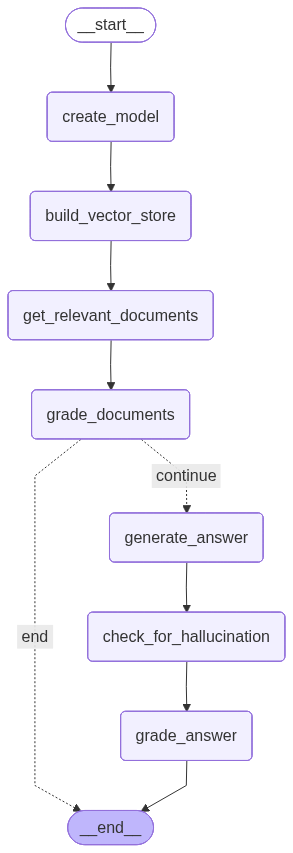

In [52]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())